This project analyzes 91,395 Indonesian earthquake records (2009–2022) to discover hidden spatial-temporal relationships between earthquake regions. Instead of predicting earthquakes, the analysis applies Association Rule Mining (Apriori) to identify recurring regional co-occurrence patterns. The project demonstrates an end-to-end data science workflow, including data quality assessment, exploratory analysis, feature engineering, transaction engineering, association rule mining, and interpretation of the discovered patterns.

# 1. Data/Business Understanding

Earthquake catalogs contain thousands of historical events describing when and where earthquakes occurred.

However, these records do not directly reveal relationships between regions or recurring seismic patterns.

This project aims to transform historical earthquake records into interpretable knowledge by discovering spatial-temporal associations among earthquake regions.

# 2. Problem Statement

Although earthquake catalogs provide detailed event information, they do not explain:

- Which regions frequently experience earthquakes together?
- How strong are these regional associations?
- Are there recurring spatial-temporal patterns?

Answering these questions requires a pattern discovery approach rather than predictive modeling.

# 3. Project Objectives

The objectives of this project are:

- Explore the characteristics of Indonesian earthquake data.
- Transform seismic events into transaction data.
- Discover association rules using the Apriori algorithm.
- Evaluate the discovered rules using support, confidence, and lift.
- Interpret the discovered patterns from a seismic perspective.

# 4. Dataset Overview

Source:
Indonesian Earthquake Catalog (BMKG)

Time Period:
2009–2022

Records:
91,395 earthquake events

Features:
- Date
- Time
- Latitude
- Longitude
- Depth
- Magnitude
- Region

Data Type:
Spatial-temporal earthquake observations.

# Implementation

## 5. Environment Setup

In [3]:
# ==========================================================
# Environment Setup
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Association Rule Mining
from mlxtend.frequent_patterns import apriori, association_rules

# Utilities
from pathlib import Path
import warnings

# Ignore unnecessary warnings
warnings.filterwarnings("ignore")

# ----------------------------------------------------------
# Display configuration
# ----------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

np.set_printoptions(precision=4, suppress=True)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

print("Environment setup completed successfully.")

Environment setup completed successfully.


## 6. Data Loading



The earthquake dataset is loaded into a Pandas DataFrame.

This section verifies that the dataset has been successfully loaded and provides a quick overview of its structure before any preprocessing is performed.

In [4]:
# ==========================================================
# Data Loading
# ==========================================================

# Define project path
PROJECT_DIR = Path.cwd().parent
DATA_PATH = PROJECT_DIR / "data" / "raw" / "earthquake.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)



In [5]:
df.head()

,date,time,latitude,longitude,depth,magnitude,remark
0,01/01/2009,18:37:24.148,-4.37,101.12,10,5.1,Southern Sumatra - Indonesia
1,01/01/2009,16:57:53.325,-4.42,101.07,10,5.3,Southern Sumatra - Indonesia
2,01/01/2009,10:35:34.583,1.42,121.99,10,5.0,Minahassa Peninsula - Sulawesi
3,01/01/2009,08:42:12.410,1.47,122.12,10,4.5,Minahassa Peninsula - Sulawesi
4,01/01/2009,05:27:19.531,0.77,121.22,10,4.9,Minahassa Peninsula - Sulawesi


In [6]:
df.tail()

,date,time,latitude,longitude,depth,magnitude,remark
91390,31/12/2022,09:03:56.877,1.56,124.36,230,4.1,Minahassa Peninsula - Sulawesi
91391,31/12/2022,08:39:11.537,3.71,97.66,10,3.4,Northern Sumatra - Indonesia
91392,31/12/2022,05:00:55.638,0.35,122.01,167,2.7,Minahassa Peninsula - Sulawesi
91393,31/12/2022,04:40:29.724,-8.98,116.80,13,2.6,Sumbawa Region - Indonesia
91394,31/12/2022,04:12:50.582,5.17,94.91,22,3.5,Northern Sumatra - Indonesia


In [7]:
print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows   : 91,395
Columns: 7


In [8]:
df.columns

Index(['date', 'time', 'latitude', 'longitude', 'depth', 'magnitude',
       'remark'],
      dtype='str')

## 7. Data Quality Assessment

Before conducting any analysis, the dataset quality must be evaluated.

This section checks:

- Data types
- Missing values
- Duplicate records
- Basic descriptive statistics

These checks ensure that the dataset is suitable for further analysis.


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 91395 entries, 0 to 91394
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       91395 non-null  str    
 1   time       91395 non-null  str    
 2   latitude   91395 non-null  float64
 3   longitude  91395 non-null  float64
 4   depth      91395 non-null  int64  
 5   magnitude  91395 non-null  float64
 6   remark     91395 non-null  str    
dtypes: float64(3), int64(1), str(3)
memory usage: 8.7 MB


In [10]:
# cek missing value

df.isnull().sum()

date         0
time         0
latitude     0
longitude    0
depth        0
magnitude    0
remark       0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(2687)

In [12]:
summary = pd.DataFrame({
    "Metric":[
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Value":[
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

summary

,Metric,Value
0,Rows,91395
1,Columns,7
2,Missing Values,0
3,Duplicate Rows,2687


### Interpretation

The dataset contains:

- 91,395 earthquake records.
- Seven variables.
- No missing values.
- 2,687 duplicated records.

The duplicated observations will be investigated before preprocessing.

## 8. Data Preparation

This section prepares the dataset for exploratory analysis and Association Rule Mining.

The preprocessing steps include:

- Removing duplicate records
- Converting date columns
- Creating datetime values
- Extracting temporal attributes

In [13]:
df = df.drop_duplicates().reset_index(drop=True)

print(df.shape)

(88708, 7)


In [14]:
df.head(5)

,date,time,latitude,longitude,depth,magnitude,remark
0,01/01/2009,18:37:24.148,-4.37,101.12,10,5.1,Southern Sumatra - Indonesia
1,01/01/2009,16:57:53.325,-4.42,101.07,10,5.3,Southern Sumatra - Indonesia
2,01/01/2009,10:35:34.583,1.42,121.99,10,5.0,Minahassa Peninsula - Sulawesi
3,01/01/2009,08:42:12.410,1.47,122.12,10,4.5,Minahassa Peninsula - Sulawesi
4,01/01/2009,05:27:19.531,0.77,121.22,10,4.9,Minahassa Peninsula - Sulawesi


In [15]:
# 2. Create datetime
df["datetime"] = pd.to_datetime(
    df["date"] + " " + df["time"],
    format="%d/%m/%Y %H:%M:%S.%f"
)

In [16]:
df.head(5)

,date,time,latitude,longitude,depth,magnitude,remark,datetime
0,01/01/2009,18:37:24.148,-4.37,101.12,10,5.1,Southern Sumatra - Indonesia,2009-01-01 18:37:24.148
1,01/01/2009,16:57:53.325,-4.42,101.07,10,5.3,Southern Sumatra - Indonesia,2009-01-01 16:57:53.325
2,01/01/2009,10:35:34.583,1.42,121.99,10,5.0,Minahassa Peninsula - Sulawesi,2009-01-01 10:35:34.583
3,01/01/2009,08:42:12.410,1.47,122.12,10,4.5,Minahassa Peninsula - Sulawesi,2009-01-01 08:42:12.410
4,01/01/2009,05:27:19.531,0.77,121.22,10,4.9,Minahassa Peninsula - Sulawesi,2009-01-01 05:27:19.531


In [17]:
# 3. Extract temporal features
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour

In [18]:
df.head(5)

,date,time,latitude,longitude,depth,magnitude,remark,datetime,year,month,day,hour
0,01/01/2009,18:37:24.148,-4.37,101.12,10,5.1,Southern Sumatra - Indonesia,2009-01-01 18:37:24.148,2009,1,1,18
1,01/01/2009,16:57:53.325,-4.42,101.07,10,5.3,Southern Sumatra - Indonesia,2009-01-01 16:57:53.325,2009,1,1,16
2,01/01/2009,10:35:34.583,1.42,121.99,10,5.0,Minahassa Peninsula - Sulawesi,2009-01-01 10:35:34.583,2009,1,1,10
3,01/01/2009,08:42:12.410,1.47,122.12,10,4.5,Minahassa Peninsula - Sulawesi,2009-01-01 08:42:12.410,2009,1,1,8
4,01/01/2009,05:27:19.531,0.77,121.22,10,4.9,Minahassa Peninsula - Sulawesi,2009-01-01 05:27:19.531,2009,1,1,5


In [19]:
# 4. Convert date if needed
df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y"
)

In [20]:
df.head(5)

,date,time,latitude,longitude,depth,magnitude,remark,datetime,year,month,day,hour
0,2009-01-01,18:37:24.148,-4.37,101.12,10,5.1,Southern Sumatra - Indonesia,2009-01-01 18:37:24.148,2009,1,1,18
1,2009-01-01,16:57:53.325,-4.42,101.07,10,5.3,Southern Sumatra - Indonesia,2009-01-01 16:57:53.325,2009,1,1,16
2,2009-01-01,10:35:34.583,1.42,121.99,10,5.0,Minahassa Peninsula - Sulawesi,2009-01-01 10:35:34.583,2009,1,1,10
3,2009-01-01,08:42:12.410,1.47,122.12,10,4.5,Minahassa Peninsula - Sulawesi,2009-01-01 08:42:12.410,2009,1,1,8
4,2009-01-01,05:27:19.531,0.77,121.22,10,4.9,Minahassa Peninsula - Sulawesi,2009-01-01 05:27:19.531,2009,1,1,5


In [21]:
df["weekday"] = df["datetime"].dt.day_name()

In [22]:
df.head()

,date,time,latitude,longitude,depth,magnitude,remark,datetime,year,month,day,hour,weekday
0,2009-01-01,18:37:24.148,-4.37,101.12,10,5.1,Southern Sumatra - Indonesia,2009-01-01 18:37:24.148,2009,1,1,18,Thursday
1,2009-01-01,16:57:53.325,-4.42,101.07,10,5.3,Southern Sumatra - Indonesia,2009-01-01 16:57:53.325,2009,1,1,16,Thursday
2,2009-01-01,10:35:34.583,1.42,121.99,10,5.0,Minahassa Peninsula - Sulawesi,2009-01-01 10:35:34.583,2009,1,1,10,Thursday
3,2009-01-01,08:42:12.410,1.47,122.12,10,4.5,Minahassa Peninsula - Sulawesi,2009-01-01 08:42:12.410,2009,1,1,8,Thursday
4,2009-01-01,05:27:19.531,0.77,121.22,10,4.9,Minahassa Peninsula - Sulawesi,2009-01-01 05:27:19.531,2009,1,1,5,Thursday


In [23]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 88708 entries, 0 to 88707
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       88708 non-null  datetime64[us]
 1   time       88708 non-null  str           
 2   latitude   88708 non-null  float64       
 3   longitude  88708 non-null  float64       
 4   depth      88708 non-null  int64         
 5   magnitude  88708 non-null  float64       
 6   remark     88708 non-null  str           
 7   datetime   88708 non-null  datetime64[us]
 8   year       88708 non-null  int32         
 9   month      88708 non-null  int32         
 10  day        88708 non-null  int32         
 11  hour       88708 non-null  int32         
 12  weekday    88708 non-null  str           
dtypes: datetime64[us](2), float64(3), int32(4), int64(1), str(3)
memory usage: 11.0 MB


In [24]:
processed_path = (

    PROJECT_DIR

    / "data"

    / "processed"

    / "earthquake_processed.csv"

)

df.to_csv(

    processed_path,

    index=False

)

### Interpretation

The dataset has been successfully prepared.

Date and time variables have been converted into appropriate datetime objects, duplicate records have been removed, and additional temporal features have been created.

The processed dataset is now ready for exploratory analysis.

## 9. EDA

### Overview Numerical Feature

Before exploring individual variables, a statistical summary is generated to understand the central tendency and variability of each numerical feature.

In [25]:
df[["latitude","longitude","depth","magnitude"]].describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,88708.0,-3.429591,4.348787,-11.00,-7.93,-2.92,0.11,6.0
longitude,88708.0,119.127935,10.747156,94.02,113.49,121.09,126.84,142.0
depth,88708.0,48.328257,75.703764,2.00,10.00,15.00,52.00,750.0
magnitude,88708.0,3.549652,0.800637,1.00,3.00,3.50,4.10,7.9


### Distribution of Earthquake Magnitude

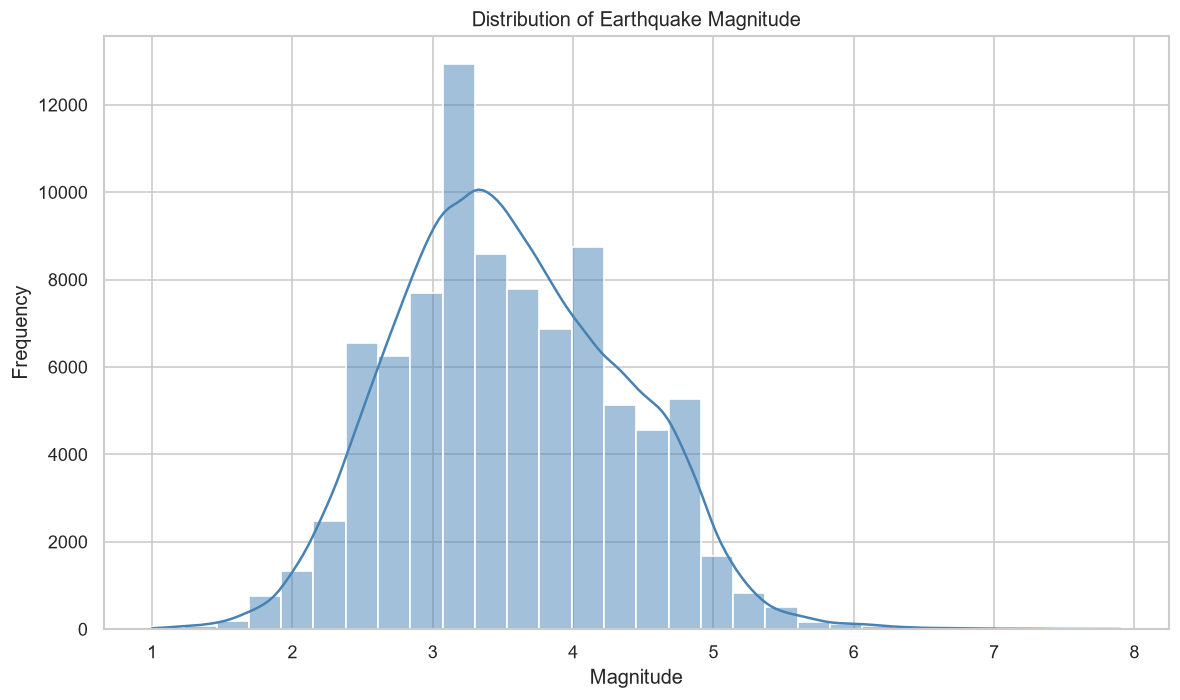

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="magnitude",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Earthquake Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"magnitude_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Most earthquakes are concentrated between magnitude 3.0 and 4.0, while large earthquakes (M ≥ 6.0) occur relatively infrequently.

### Distribution of Earthquake Depth

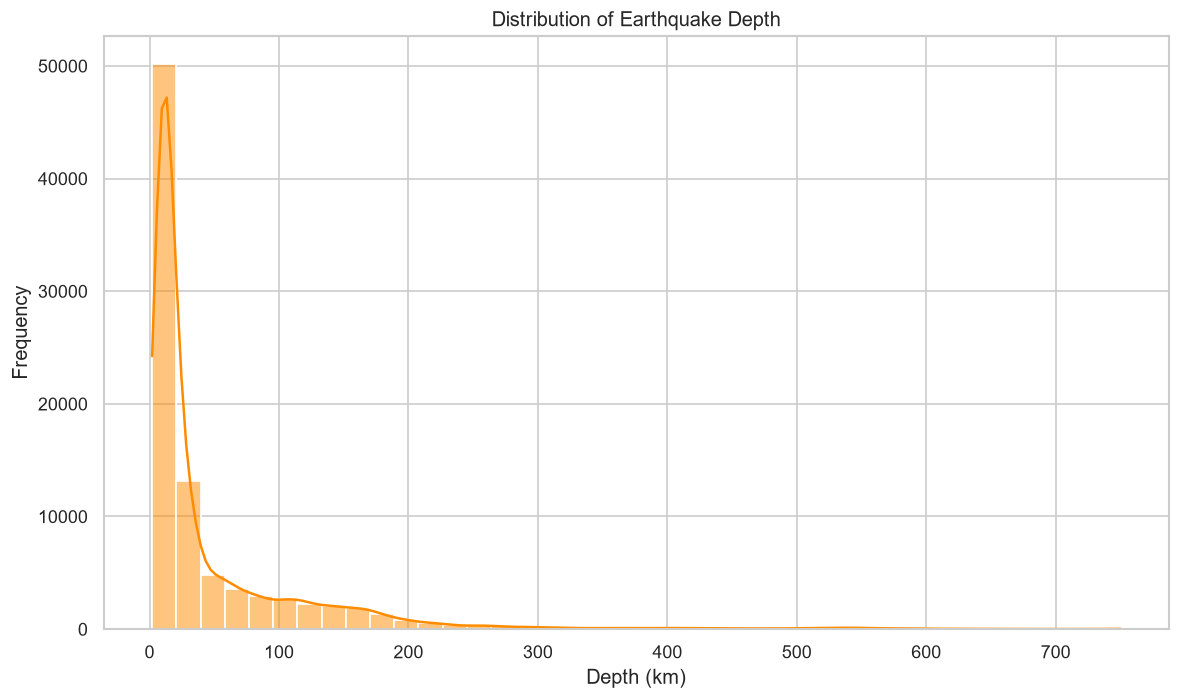

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="depth",
    bins=40,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Earthquake Depth")

plt.xlabel("Depth (km)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"depth_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The majority of earthquakes are shallow earthquakes (<30 km), while very deep earthquakes represent only a small proportion of the dataset.

### Most Active Earthquake Regions

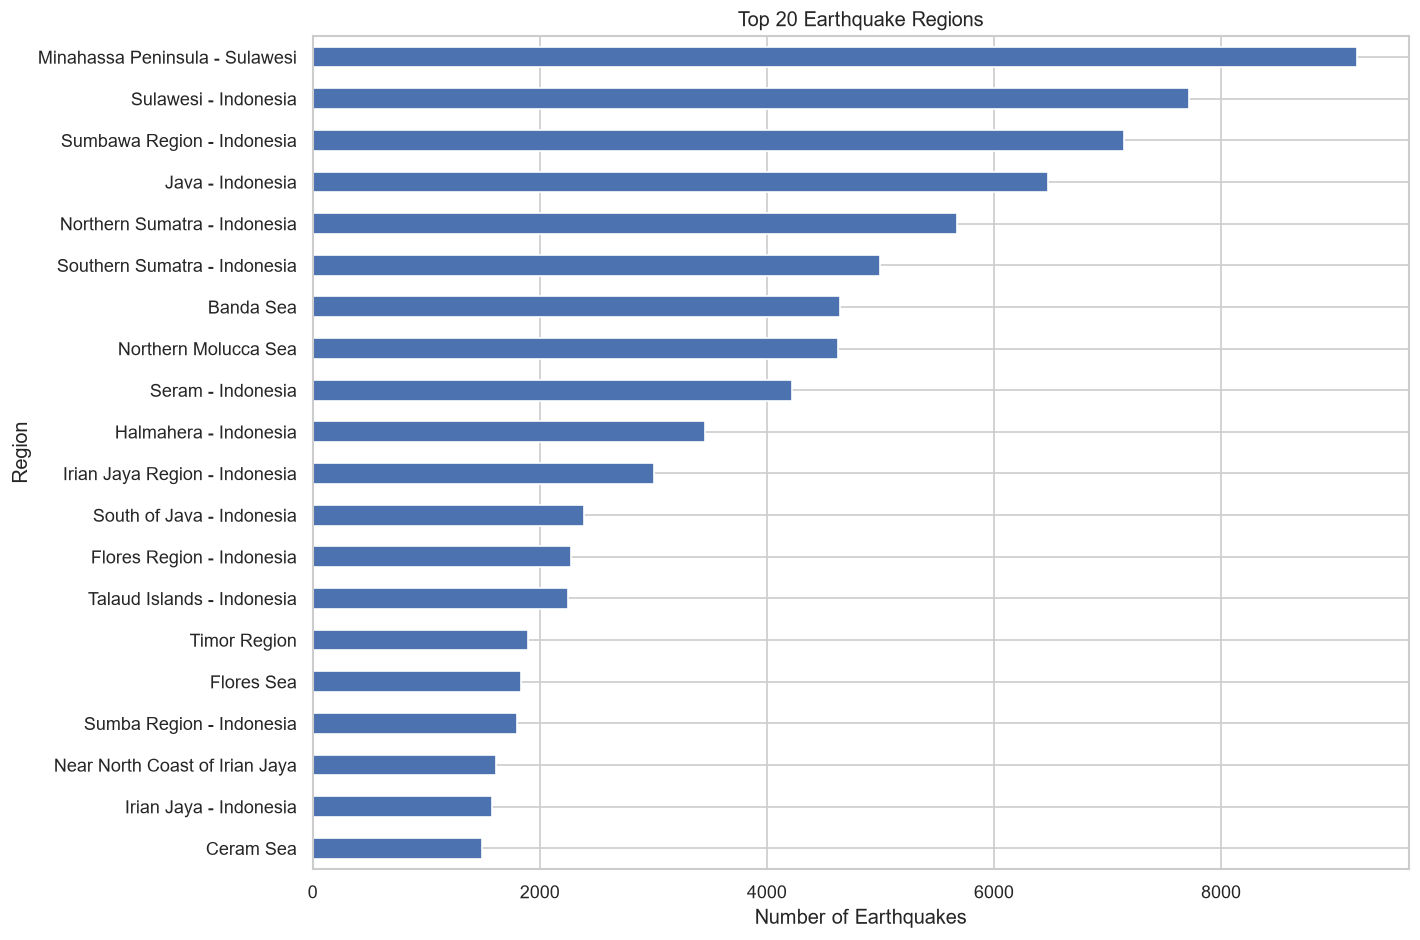

In [28]:
top20 = (
    df["remark"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(12,8))

top20.plot(kind="barh")

plt.title("Top 20 Earthquake Regions")

plt.xlabel("Number of Earthquakes")

plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"top20_regions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Minahassa Peninsula, Sulawesi, and Sumbawa Region recorded the highest number of earthquakes during the study period.

### Earthquake Activity Over Time

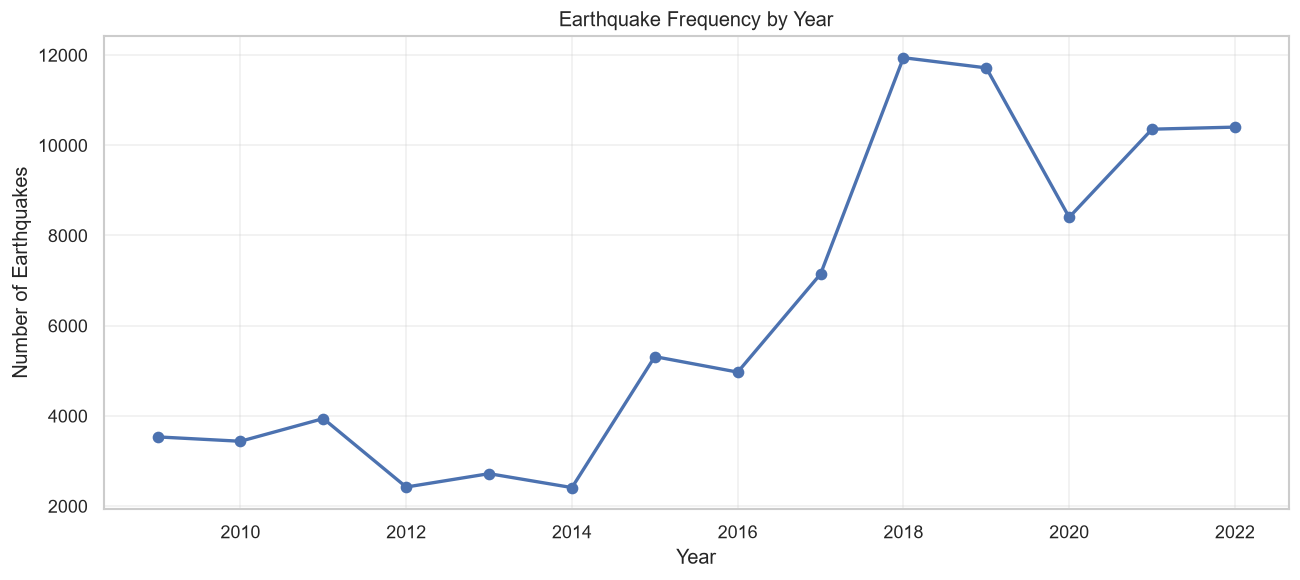

In [29]:
events_year = df.groupby("year").size()

plt.figure(figsize=(11,5))

events_year.plot(
    marker="o",
    linewidth=2
)

plt.title("Earthquake Frequency by Year")

plt.xlabel("Year")

plt.ylabel("Number of Earthquakes")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"earthquake_per_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Earthquake frequency varies from year to year, reflecting natural seismic variability and possible differences in event recording.

### Relationship Between Magnitude and Depth

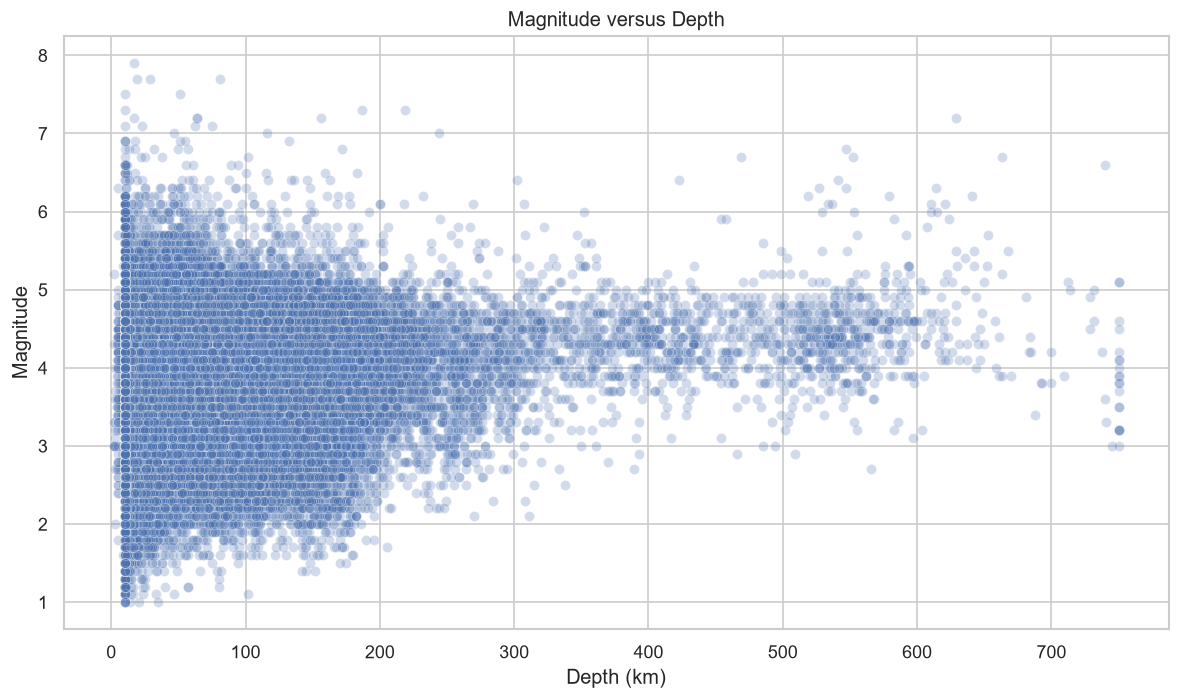

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="depth",
    y="magnitude",
    alpha=0.25
)

plt.title("Magnitude versus Depth")

plt.xlabel("Depth (km)")

plt.ylabel("Magnitude")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"magnitude_vs_depth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

No clear linear relationship is observed between earthquake magnitude and focal depth.

### Correlation Analysis

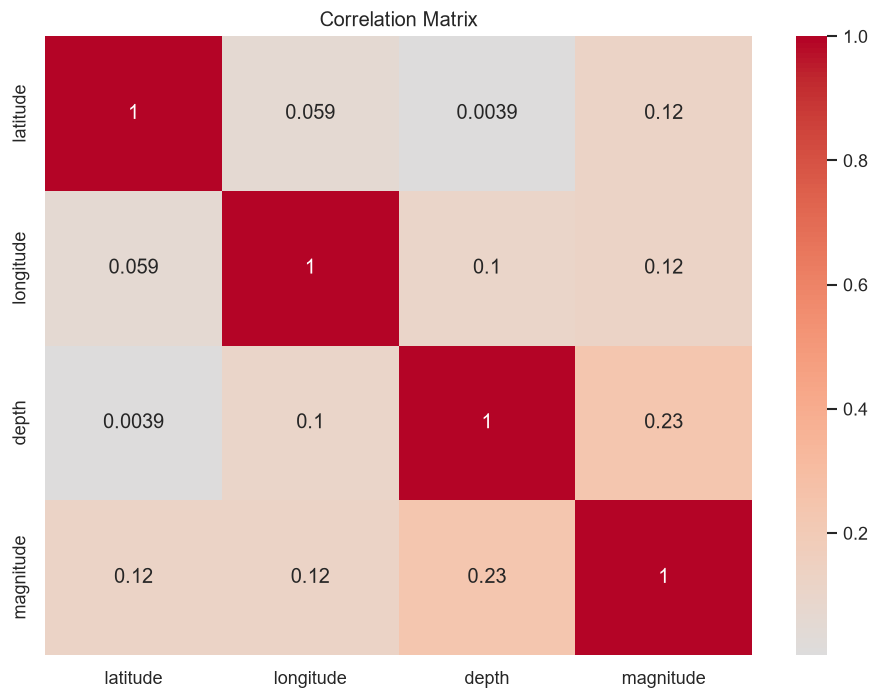

In [31]:
corr = df[
    [
        "latitude",
        "longitude",
        "depth",
        "magnitude"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The numerical variables exhibit weak correlations, indicating that each variable contributes different information about earthquake characteristics.

### Summary of Exploratory Findings



The exploratory analysis reveals several important characteristics of the dataset:

- The earthquake catalog is dominated by low-to-moderate magnitude events.
- Most earthquakes occur at shallow depths (<30 km).
- Seismic activity is concentrated in several tectonically active regions, particularly Minahassa Peninsula and Sulawesi.
- Earthquake frequency varies across years without a consistent long-term trend.
- Numerical variables exhibit relatively weak linear correlations, supporting the need for pattern discovery techniques such as Association Rule Mining rather than simple linear modeling.

These findings provide the foundation for the feature engineering and transaction engineering stages in the next section.

# 10. Data Transformation for Association Rule Mining



## Why Data Transformation Is Necessary

The earthquake catalog is organized as individual seismic events, where each row represents a single earthquake occurrence.

However, Association Rule Mining does not analyze individual records directly. Instead, it requires the data to be represented as a collection of **transactions**, where each transaction contains a set of related items.

Therefore, before applying the Apriori algorithm, the earthquake records must be transformed into a transaction-based representation.

In this project:

- **Item** : Earthquake Region (`remark`)
- **Transaction Unit** : One calendar day
- **Objective** : Discover earthquake regions that frequently co-occur within the same observation window.

## 10.1 Item Selection

The project aims to answer the following research question:

> Which earthquake regions frequently co-occur within the same observation window?

Therefore, the **earthquake region (`remark`)** is selected as the primary item because it directly represents the geographical location where each earthquake occurred.

Other variables such as latitude, longitude, depth, and magnitude are useful for descriptive analysis but are not required to answer the primary research question in this project.

## 10.2 Transaction Definition

Unlike market basket analysis, earthquake datasets do not naturally contain transactions.

Therefore, a transaction must be defined based on an observation window.

In this project, all earthquake events occurring within the same calendar day are grouped into a single transaction.

This assumption enables the analysis of regional earthquake co-occurrence within a consistent temporal window.

In [32]:
print("Original Dataset")
df[["date","remark"]].head(15)

Original Dataset


,date,remark
0,2009-01-01,Southern Sumatra - Indonesia
1,2009-01-01,Southern Sumatra - Indonesia
2,2009-01-01,Minahassa Peninsula - Sulawesi
3,2009-01-01,Minahassa Peninsula - Sulawesi
4,2009-01-01,Minahassa Peninsula - Sulawesi
5,2009-01-01,Banda Sea
6,2009-01-02,Banda Sea
7,2009-01-02,Banda Sea
8,2009-01-02,Bali Sea
9,2009-01-02,Minahassa Peninsula - Sulawesi


In [33]:
transactions = (
    df
    .groupby("date")["remark"]
    .apply(lambda x: sorted(set(x)))
    .reset_index()
)

transactions.columns = ["transaction_date", "items"]

transactions.head()

,transaction_date,items
0,2009-01-01,"[Banda Sea, Minahassa Peninsula - Sulawesi, Southern Sumatra - Indonesia]"
1,2009-01-02,"[Bali Sea, Banda Sea, Ceram Sea, Minahassa Peninsula - Sulawesi, Sulawesi - Indonesia]"
2,2009-01-03,"[Banda Sea, Borneo, Flores Region - Indonesia, Halmahera - Indonesia, Irian Jaya Region - Indonesia, Southern Molucca Sea, Talaud Islands - Indonesia]"
3,2009-01-04,"[Celebes Sea, Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Minahassa Peninsula - Sulawesi, Talaud Islands - Indonesia]"
4,2009-01-05,"[Celebes Sea, Irian Jaya Region - Indonesia, Southern Sumatra - Indonesia, Talaud Islands - Indonesia]"


Each transaction now represents one calendar day, containing all unique earthquake regions that experienced seismic activity during that day.

This transaction-based representation is the required input format for Association Rule Mining.

In [34]:
transactions["n_items"] = transactions["items"].apply(len)

transactions["n_items"].describe()

count    4333.000000
mean       10.527579
std         3.997170
min         1.000000
25%         8.000000
50%        10.000000
75%        13.000000
max        27.000000
Name: n_items, dtype: float64

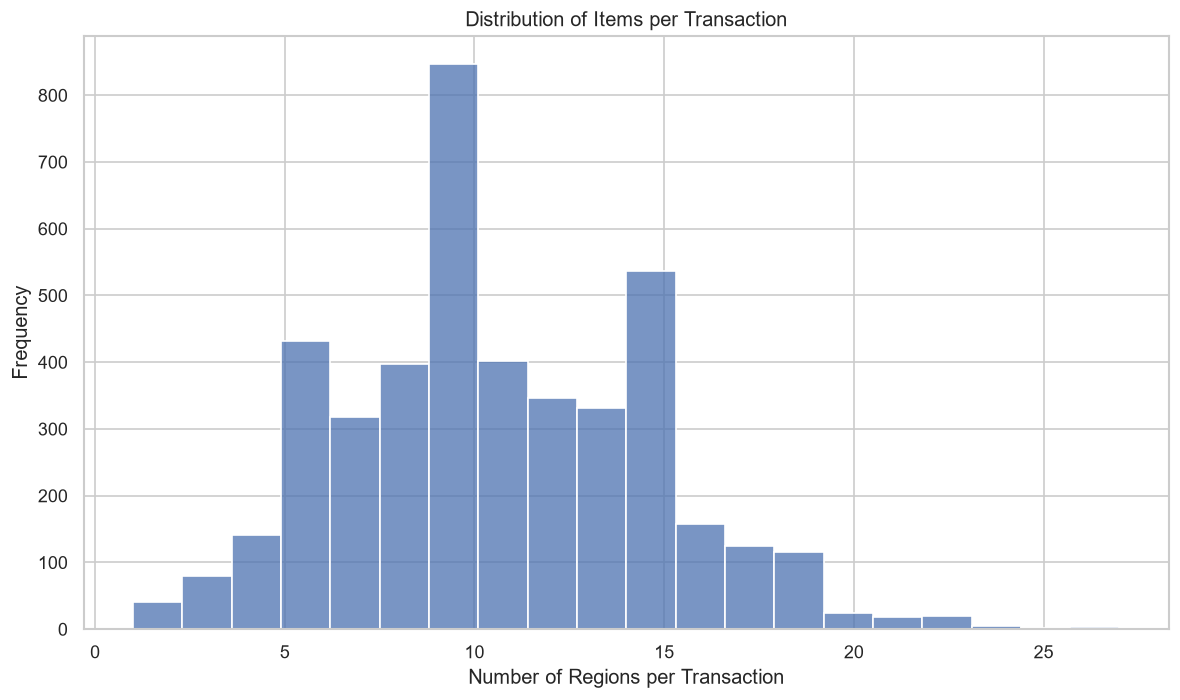

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(
    transactions["n_items"],
    bins=20
)

plt.xlabel("Number of Regions per Transaction")

plt.ylabel("Frequency")

plt.title("Distribution of Items per Transaction")

plt.tight_layout()

plt.savefig(PROJECT_DIR/"images"/"transaction_size_distribution.png", dpi=300)

plt.show()

A total of 4,333 daily transactions were generated from the earthquake catalog. Each transaction represents all unique earthquake regions experiencing seismic activity within the same calendar day.

The average transaction contains approximately 10.5 unique regions, with a median of 10 regions. Most daily transactions contain between 8 and 13 regions, indicating sufficient item diversity for Association Rule Mining.

The relatively balanced transaction size suggests that defining one calendar day as the observation window is appropriate for discovering regional co-occurrence patterns.

# 11. Transaction Encoding



## Why Transaction Encoding?

The Apriori algorithm requires a binary transaction matrix where:

- Each row represents one transaction.
- Each column represents one item (earthquake region).
- A value of **True (1)** indicates that the region appears in the transaction.
- A value of **False (0)** indicates that the region does not appear.

Therefore, the list-based transaction dataset is transformed into a one-hot encoded matrix before applying Association Rule Mining.


In [36]:
from mlxtend.preprocessing import TransactionEncoder

In [37]:
# ==========================================================
# Transaction Encoding
# ==========================================================

te = TransactionEncoder()

encoded = te.fit(transactions["items"]).transform(transactions["items"])

transaction_matrix = pd.DataFrame(
    encoded,
    columns=te.columns_
)

transaction_matrix.head()

,Arafura Sea,Aru Islands Region - Indonesia,Bali Region - Indonesia,Bali Sea,Banda Sea,Borneo,Buru - Indonesia,Celebes Sea,Ceram Sea,East of Philippine Islands,Flores Region - Indonesia,Flores Sea,Halmahera - Indonesia,Irian Jaya - Indonesia,Irian Jaya Region - Indonesia,Java - Indonesia,Java Sea,Malay Peninsula,Minahassa Peninsula - Sulawesi,Mindanao - Philippines,Near N. Coast of New Guinea - PNG.,Near North Coast of Irian Jaya,Near S. Coast of New Guinea - PNG.,Near South Coast of Irian Jaya,New Guinea - Papua New Guinea,Ninigo Islands Region - P.N.G.,North of Halmahera - Indonesia,Northern Molucca Sea,Northern Sumatra - Indonesia,Off West Coast of Northern Sumatra,Philippine Islands Region,Savu Sea,Seram - Indonesia,South China Sea,South Indian Ocean,South of Bali - Indonesia,South of Java - Indonesia,South of Sumbawa - Indonesia,Southern Molucca Sea,Southern Sumatra - Indonesia,Southwest of Sumatra - Indonesia,Sulawesi - Indonesia,Sulu Archipelago - Philippines,Sumba Region - Indonesia,Sumbawa Region - Indonesia,Sunda Strait - Indonesia,Talaud Islands - Indonesia,Tanimbar Islands Reg. - Indonesia,Timor Region,Timor Sea,W. Caroline Islands - Micronesia
0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False


In [39]:
print("="*60)
print("Transaction Matrix Information")
print("="*60)

print(f"Transactions : {transaction_matrix.shape[0]:,}")
print(f"Items        : {transaction_matrix.shape[1]}")
print(f"Matrix Size  : {transaction_matrix.shape}")


Transaction Matrix Information
Transactions : 4,333
Items        : 51
Matrix Size  : (4333, 51)


In [40]:
density = transaction_matrix.mean().mean()

print(f"Matrix Density : {density:.4f}")

print(f"Percentage of Active Items : {density*100:.2f}%")

Matrix Density : 0.2064
Percentage of Active Items : 20.64%


In [41]:
transaction_matrix.to_csv(
    PROJECT_DIR / "data" / "processed" / "transaction_matrix.csv",
    index=False
)

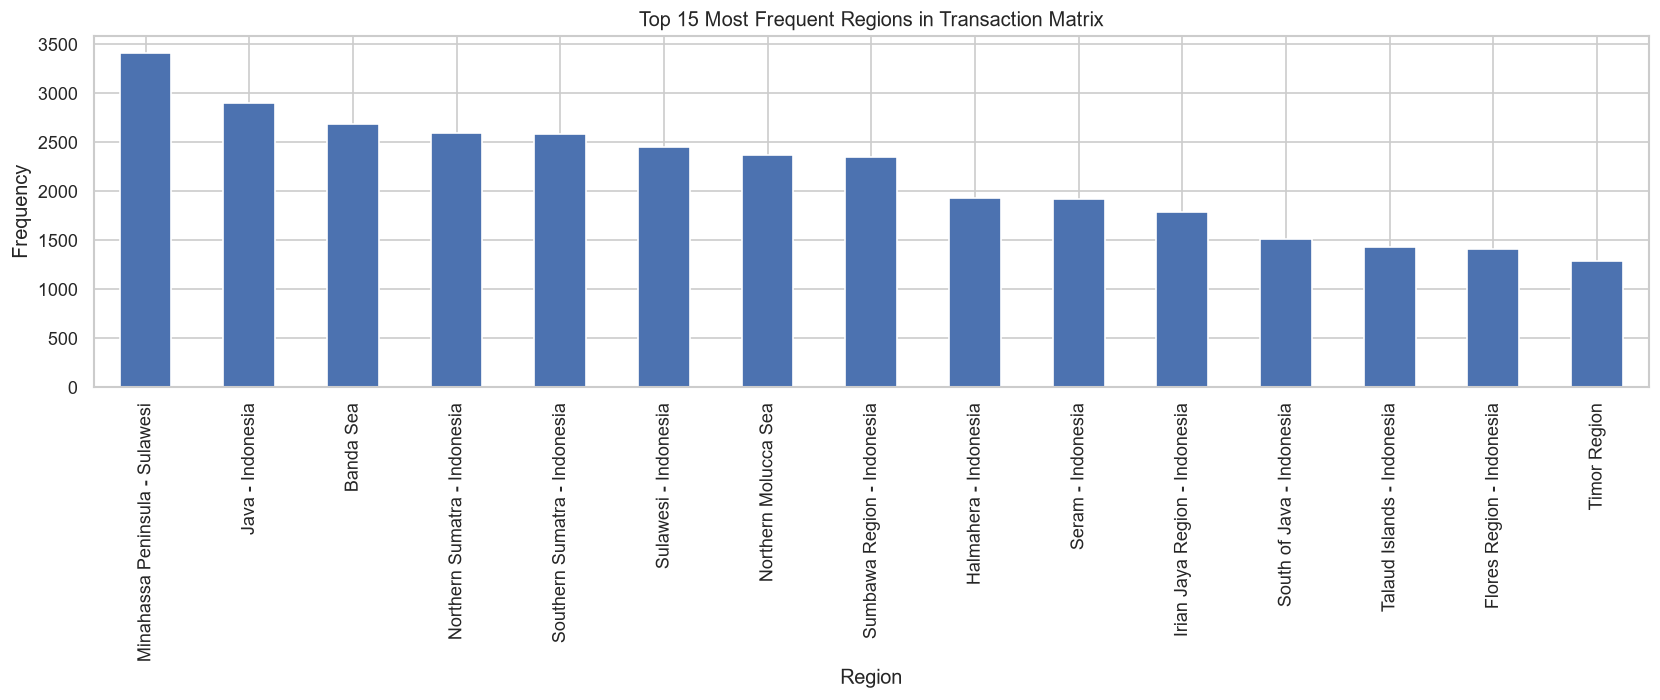

In [42]:
plt.figure(figsize=(14,6))

region_frequency = (
    transaction_matrix
    .sum()
    .sort_values(ascending=False)
)

region_frequency.head(15).plot(kind="bar")

plt.title("Top 15 Most Frequent Regions in Transaction Matrix")
plt.ylabel("Frequency")
plt.xlabel("Region")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "images" / "transaction_frequency.png",
    dpi=300
)

plt.show()

In [43]:
print("Number of Transactions :", transaction_matrix.shape[0])
print("Number of Regions      :", transaction_matrix.shape[1])

print("\nTop 10 Most Frequent Regions")
display(region_frequency.head(10))

print("\nBottom 10 Least Frequent Regions")
display(region_frequency.tail(10))

Number of Transactions : 4333
Number of Regions      : 51

Top 10 Most Frequent Regions


Minahassa Peninsula - Sulawesi    3412
Java - Indonesia                  2906
Banda Sea                         2685
Northern Sumatra - Indonesia      2593
Southern Sumatra - Indonesia      2585
Sulawesi - Indonesia              2453
Northern Molucca Sea              2368
Sumbawa Region - Indonesia        2353
Halmahera - Indonesia             1932
Seram - Indonesia                 1917
dtype: int64


Bottom 10 Least Frequent Regions


South China Sea                       22
W. Caroline Islands - Micronesia      12
East of Philippine Islands            11
Sulu Archipelago - Philippines         9
Malay Peninsula                        8
Arafura Sea                            6
South Indian Ocean                     3
Near South Coast of Irian Jaya         3
Near S. Coast of New Guinea - PNG.     2
Ninigo Islands Region - P.N.G.         1
dtype: int64

# 12. Frequent Itemset Mining



## Why Frequent Itemset Mining?

After converting the earthquake records into a transaction matrix, the next step is to identify combinations of earthquake regions that frequently appear together.

Frequent Itemset Mining aims to discover groups of earthquake regions that consistently co-occur across multiple daily transactions.

These frequent itemsets serve as the foundation for generating association rules in the next stage.



## Minimum Support Selection

The Apriori algorithm requires a minimum support threshold to determine whether an itemset occurs frequently enough to be considered meaningful.

Instead of selecting the threshold arbitrarily, several candidate values are evaluated to understand their impact on the number of discovered frequent itemsets.

The selected threshold should produce a sufficient number of meaningful patterns while avoiding excessive insignificant combinations.

In [45]:
# ==========================================================
# Candidate Minimum Support Values
# ==========================================================

candidate_supports = [0.10, 0.08, 0.05, 0.03, 0.02, 0.01]

candidate_supports

[0.1, 0.08, 0.05, 0.03, 0.02, 0.01]

In [46]:
# ==========================================================
# Experiment: Minimum Support Selection
# ==========================================================

support_results = []

for support in candidate_supports:

    frequent_itemsets = apriori(
        transaction_matrix,
        min_support=support,
        use_colnames=True
    )

    support_results.append({
        "Minimum Support": support,
        "Frequent Itemsets": len(frequent_itemsets)
    })

support_results = pd.DataFrame(support_results)

support_results

,Minimum Support,Frequent Itemsets
0,0.10,1374
1,0.08,2416
2,0.05,7218
3,0.03,21920
4,0.02,49986
5,0.01,187737


In [49]:
candidate_supports2 = [
    0.050,
    0.045,
    0.040,
    0.035,
    0.030
]

# ==========================================================
# Minimum Support Selection part 2
# ==========================================================

support_results = []

for support in candidate_supports2:

    frequent_itemsets = apriori(
        transaction_matrix,
        min_support=support,
        use_colnames=True
    )

    support_results.append({
        "Minimum Support": support,
        "Frequent Itemsets": len(frequent_itemsets)
    })

support_results = pd.DataFrame(support_results)

support_results

,Minimum Support,Frequent Itemsets
0,0.050,7218
1,0.045,9100
2,0.040,11708
3,0.035,15761
4,0.030,21920


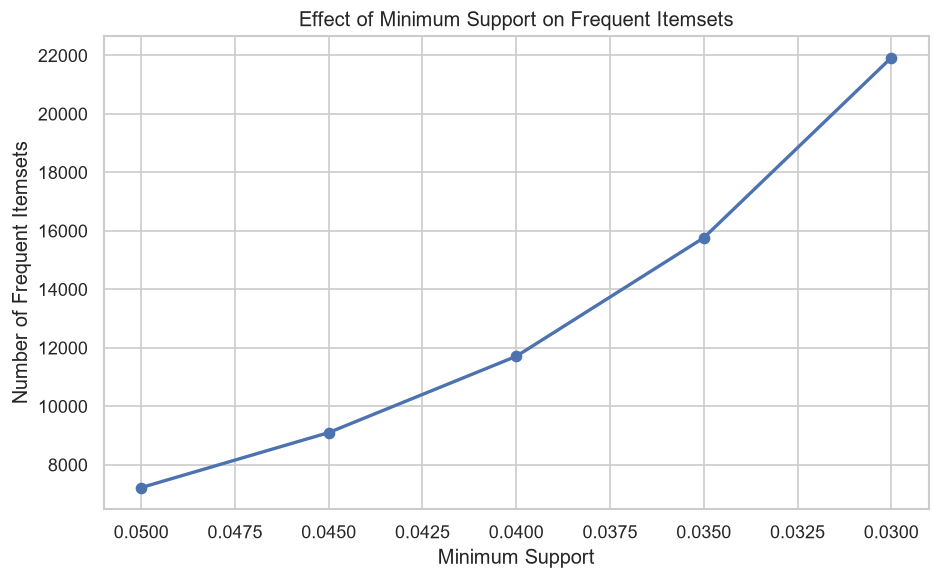

In [50]:
# ==========================================================
# Visualization
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    support_results["Minimum Support"],
    support_results["Frequent Itemsets"],
    marker="o",
    linewidth=2
)

plt.gca().invert_xaxis()

plt.xlabel("Minimum Support")

plt.ylabel("Number of Frequent Itemsets")

plt.title("Effect of Minimum Support on Frequent Itemsets")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"minimum_support_analysis.png",
    dpi=300
)

plt.show()

In [51]:
# ==========================================================
# Frequent Itemset Mining
# ==========================================================

MIN_SUPPORT = 0.04

frequent_itemsets = apriori(
    transaction_matrix,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

print("="*60)
print("Frequent Itemset Mining")
print("="*60)

print(f"Minimum Support : {MIN_SUPPORT}")
print(f"Frequent Itemsets Found : {len(frequent_itemsets):,}")

Frequent Itemset Mining
Minimum Support : 0.04
Frequent Itemsets Found : 11,708


In [54]:
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

frequent_itemsets.head()

,support,itemsets,length
0,0.142626,frozenset({Bali Region - Indonesia}),1
1,0.122086,frozenset({Bali Sea}),1
2,0.619663,frozenset({Banda Sea}),1
3,0.104085,frozenset({Celebes Sea}),1
4,0.237941,frozenset({Ceram Sea}),1


In [55]:
frequent_itemsets["length"].value_counts().sort_index()

length
1      33
2     367
3    1667
4    3576
5    3704
6    1917
7     415
8      29
Name: count, dtype: int64

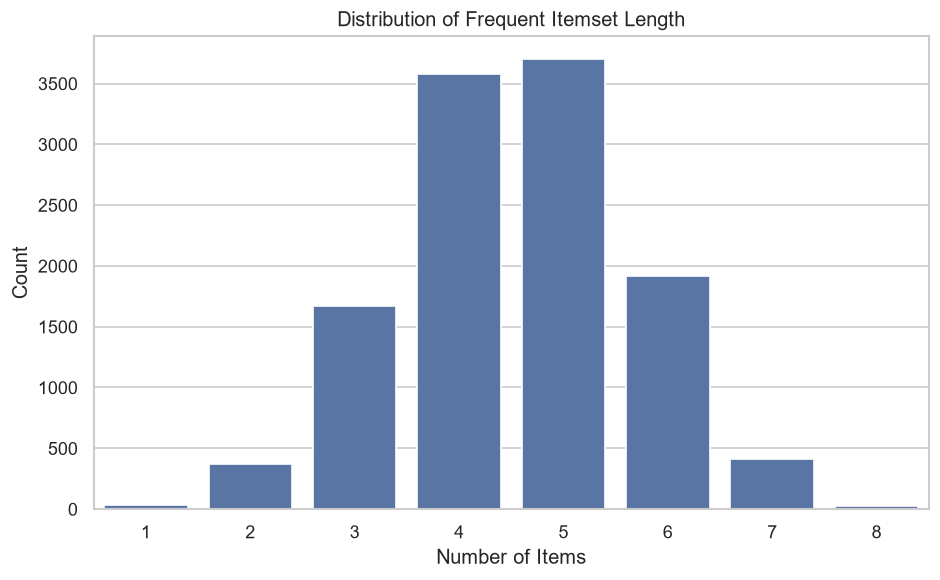

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="length",
    data=frequent_itemsets
)

plt.title("Distribution of Frequent Itemset Length")

plt.xlabel("Number of Items")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"frequent_itemset_length.png",
    dpi=300
)

plt.show()

In [57]:
frequent_itemsets.sort_values(
    "support",
    ascending=False
).head(20)

,support,itemsets,length
11,0.787445,frozenset({Minahassa Peninsula - Sulawesi}),1
10,0.670667,frozenset({Java - Indonesia}),1
2,0.619663,frozenset({Banda Sea}),1
16,0.598431,frozenset({Northern Sumatra - Indonesia}),1
24,0.596584,frozenset({Southern Sumatra - Indonesia}),1
26,0.566120,frozenset({Sulawesi - Indonesia}),1
228,0.549042,"frozenset({Java - Indonesia, Minahassa Peninsula - Sulawesi})",2
15,0.546504,frozenset({Northern Molucca Sea}),1
28,0.543042,frozenset({Sumbawa Region - Indonesia}),1
75,0.502192,"frozenset({Banda Sea, Minahassa Peninsula - Sulawesi})",2


### Interpretation

Using a minimum support threshold of **4%**, the Apriori algorithm identified **11,708 frequent itemsets**.

The majority of frequent itemsets consist of **4–5 earthquake regions**, indicating that regional earthquake activity often involves multiple regions within the same daily observation window.

Single-region itemsets with the highest support include:

- Minahassa Peninsula – Sulawesi
- Java – Indonesia
- Banda Sea
- Northern Sumatra – Indonesia
- Southern Sumatra – Indonesia

These frequent itemsets represent commonly occurring regional combinations and provide the foundation for generating association rules in the next section.

# 13. Association Rule Generation



## Why Association Rules?

Frequent itemsets only indicate which combinations of earthquake regions occur frequently.

However, they do not describe directional relationships between regions.

Association Rule Mining extends frequent itemsets by generating implication rules of the form

Antecedent → Consequent

These rules describe how the occurrence of one region is associated with the occurrence of another region.

The strength of each rule is evaluated using:

- Support
- Confidence
- Lift

Only rules satisfying predefined thresholds are retained for further interpretation.

In [58]:
# ==========================================================
# Association Rule Parameters
# ==========================================================

MIN_CONFIDENCE = 0.60
MIN_LIFT = 1.20

print(f"Minimum Confidence : {MIN_CONFIDENCE}")
print(f"Minimum Lift       : {MIN_LIFT}")

Minimum Confidence : 0.6
Minimum Lift       : 1.2


In [59]:
# ==========================================================
# Generate Association Rules
# ==========================================================

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE
)

print(f"Generated Rules : {len(rules):,}")

Generated Rules : 45,168


In [60]:
rules = rules[
    rules["lift"] >= MIN_LIFT
].copy()

print(f"Rules After Lift Filtering : {len(rules):,}")

Rules After Lift Filtering : 27,129


In [61]:
rules = rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
45093,"frozenset({Halmahera - Indonesia, Java - Indonesia, Sumbawa Region - Indonesia, Southern Sumatra - Indonesia, Irian Jaya Region - Indonesia})","frozenset({Northern Sumatra - Indonesia, Sulawesi - Indonesia, Minahassa Peninsula - Sulawesi})",0.069698,0.315024,0.043157,0.619205,1.965580,1.0,0.021201,1.798806,0.528048,0.126351,0.444076,0.378101
45048,"frozenset({Halmahera - Indonesia, Northern Molucca Sea, Java - Indonesia, Southern Sumatra - Indonesia, Irian Jaya Region - Indonesia})","frozenset({Minahassa Peninsula - Sulawesi, Sulawesi - Indonesia, Northern Sumatra - Indonesia})",0.065774,0.315024,0.040388,0.614035,1.949168,1.0,0.019667,1.774710,0.521245,0.118644,0.436528,0.371120
45070,"frozenset({Halmahera - Indonesia, Northern Molucca Sea, Java - Indonesia, Sumbawa Region - Indonesia, Irian Jaya Region - Indonesia})","frozenset({Minahassa Peninsula - Sulawesi, Sulawesi - Indonesia, Northern Sumatra - Indonesia})",0.066236,0.315024,0.040388,0.609756,1.935585,1.0,0.019522,1.755250,0.517647,0.118483,0.430281,0.368981
26697,"frozenset({Near North Coast of Irian Jaya, Talaud Islands - Indonesia, Sulawesi - Indonesia})","frozenset({Sumbawa Region - Indonesia, Northern Molucca Sea})",0.067621,0.329795,0.041311,0.610922,1.852430,1.0,0.019010,1.722545,0.493542,0.116008,0.419464,0.368092
43499,"frozenset({Halmahera - Indonesia, Java - Indonesia, Sumbawa Region - Indonesia, Southern Sumatra - Indonesia, Irian Jaya Region - Indonesia})","frozenset({Sulawesi - Indonesia, Northern Sumatra - Indonesia})",0.069698,0.371105,0.047542,0.682119,1.838074,1.0,0.021677,1.978397,0.490112,0.120892,0.494540,0.405114


In [62]:
rules["antecedents"] = rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

rules["consequents"] = rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

In [63]:
rules_display = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

rules_display.head(20)

,antecedents,consequents,support,confidence,lift
45093,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Southern Sumatra - Indonesia, Sumbawa Region - Indonesia","Minahassa Peninsula - Sulawesi, Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.043157,0.619205,1.965580
45048,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Northern Molucca Sea, Southern Sumatra - Indonesia","Minahassa Peninsula - Sulawesi, Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.040388,0.614035,1.949168
45070,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Northern Molucca Sea, Sumbawa Region - Indonesia","Minahassa Peninsula - Sulawesi, Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.040388,0.609756,1.935585
26697,"Near North Coast of Irian Jaya, Sulawesi - Indonesia, Talaud Islands - Indonesia","Northern Molucca Sea, Sumbawa Region - Indonesia",0.041311,0.610922,1.852430
43499,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Southern Sumatra - Indonesia, Sumbawa Region - Indonesia","Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.047542,0.682119,1.838074
35911,"Halmahera - Indonesia, Java - Indonesia, Near North Coast of Irian Jaya, Northern Molucca Sea","Sulawesi - Indonesia, Sumbawa Region - Indonesia",0.042926,0.648084,1.837792
35922,"Halmahera - Indonesia, Java - Indonesia, Near North Coast of Irian Jaya, Northern Sumatra - Indonesia","Sulawesi - Indonesia, Sumbawa Region - Indonesia",0.043157,0.644828,1.828559
45059,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Minahassa Peninsula - Sulawesi, Northern Molucca Sea, Sumbawa Region - Indonesia","Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.040388,0.678295,1.827768
33983,"Flores Region - Indonesia, Irian Jaya Region - Indonesia, Northern Molucca Sea, Northern Sumatra - Indonesia","Sulawesi - Indonesia, Sumbawa Region - Indonesia",0.043388,0.643836,1.825746
45084,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Minahassa Peninsula - Sulawesi, Southern Sumatra - Indonesia, Sumbawa Region - Indonesia","Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.043157,0.677536,1.825724


In [64]:
rules_display.to_csv(
    PROJECT_DIR / "results" / "association_rules.csv",
    index=False
)

### Interpretation

Association rules describe directional relationships between earthquake regions.

Unlike frequent itemsets, which simply identify commonly occurring combinations, association rules quantify how strongly the occurrence of one region implies the occurrence of another.

Rules with higher confidence indicate greater reliability, while lift values above one indicate that the association is stronger than random chance.

Only rules satisfying the predefined confidence and lift thresholds are retained for further analysis.

# 14 Rule Analysis & Visualization

In [65]:
# ==========================================================
# Rule Summary
# ==========================================================

summary = pd.DataFrame({
    "Metric":[
        "Total Rules",
        "Average Support",
        "Average Confidence",
        "Average Lift",
        "Maximum Lift",
        "Maximum Confidence"
    ],
    "Value":[
        len(rules),
        rules["support"].mean(),
        rules["confidence"].mean(),
        rules["lift"].mean(),
        rules["lift"].max(),
        rules["confidence"].max()
    ]
})

summary

,Metric,Value
0,Total Rules,27129.000000
1,Average Support,0.057301
2,Average Confidence,0.698375
3,Average Lift,1.334621
4,Maximum Lift,1.965580
5,Maximum Confidence,0.949541


In [66]:
top_rules = rules.sort_values(
    by="lift",
    ascending=False
).head(20)

top_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
45093,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Southern Sumatra - Indonesia, Sumbawa Region - Indonesia","Minahassa Peninsula - Sulawesi, Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.069698,0.315024,0.043157,0.619205,1.965580,1.0,0.021201,1.798806,0.528048,0.126351,0.444076,0.378101
45048,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Northern Molucca Sea, Southern Sumatra - Indonesia","Minahassa Peninsula - Sulawesi, Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.065774,0.315024,0.040388,0.614035,1.949168,1.0,0.019667,1.774710,0.521245,0.118644,0.436528,0.371120
45070,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Northern Molucca Sea, Sumbawa Region - Indonesia","Minahassa Peninsula - Sulawesi, Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.066236,0.315024,0.040388,0.609756,1.935585,1.0,0.019522,1.755250,0.517647,0.118483,0.430281,0.368981
26697,"Near North Coast of Irian Jaya, Sulawesi - Indonesia, Talaud Islands - Indonesia","Northern Molucca Sea, Sumbawa Region - Indonesia",0.067621,0.329795,0.041311,0.610922,1.852430,1.0,0.019010,1.722545,0.493542,0.116008,0.419464,0.368092
43499,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Southern Sumatra - Indonesia, Sumbawa Region - Indonesia","Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.069698,0.371105,0.047542,0.682119,1.838074,1.0,0.021677,1.978397,0.490112,0.120892,0.494540,0.405114
35911,"Halmahera - Indonesia, Java - Indonesia, Near North Coast of Irian Jaya, Northern Molucca Sea","Sulawesi - Indonesia, Sumbawa Region - Indonesia",0.066236,0.352643,0.042926,0.648084,1.837792,1.0,0.019569,1.839521,0.488206,0.114180,0.456380,0.384906
35922,"Halmahera - Indonesia, Java - Indonesia, Near North Coast of Irian Jaya, Northern Sumatra - Indonesia","Sulawesi - Indonesia, Sumbawa Region - Indonesia",0.066928,0.352643,0.043157,0.644828,1.828559,1.0,0.019555,1.822657,0.485623,0.114654,0.451350,0.383605
45059,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Minahassa Peninsula - Sulawesi, Northern Molucca Sea, Sumbawa Region - Indonesia","Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.059543,0.371105,0.040388,0.678295,1.827768,1.0,0.018291,1.954877,0.481558,0.103489,0.488459,0.393563
33983,"Flores Region - Indonesia, Irian Jaya Region - Indonesia, Northern Molucca Sea, Northern Sumatra - Indonesia","Sulawesi - Indonesia, Sumbawa Region - Indonesia",0.067390,0.352643,0.043388,0.643836,1.825746,1.0,0.019623,1.817581,0.484960,0.115196,0.449818,0.383436
45084,"Halmahera - Indonesia, Irian Jaya Region - Indonesia, Java - Indonesia, Minahassa Peninsula - Sulawesi, Southern Sumatra - Indonesia, Sumbawa Region - Indonesia","Northern Sumatra - Indonesia, Sulawesi - Indonesia",0.063697,0.371105,0.043157,0.677536,1.825724,1.0,0.019519,1.950280,0.483040,0.110194,0.487253,0.396915


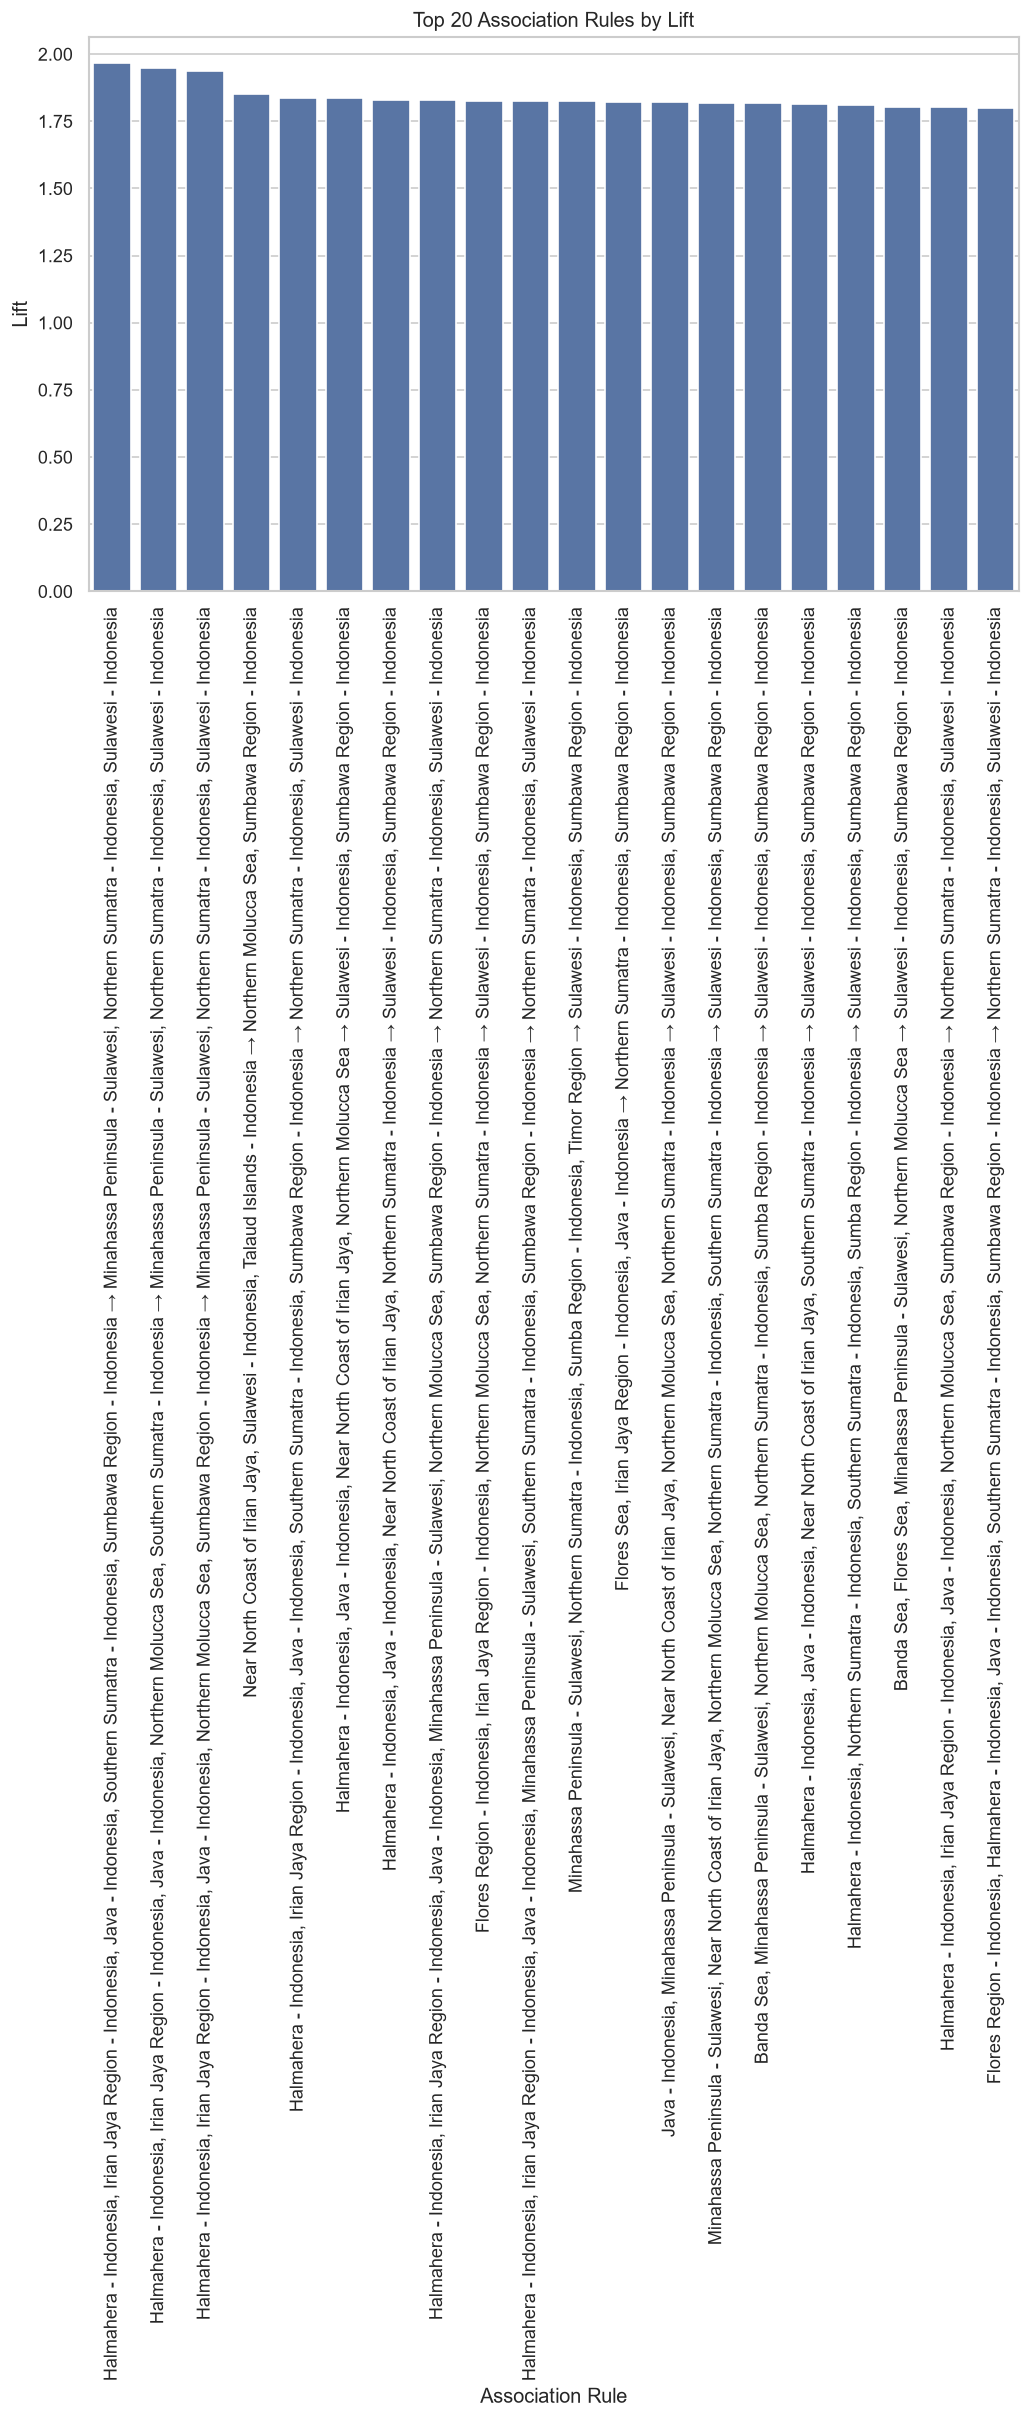

In [67]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_rules,
    y="lift",
    x=top_rules["antecedents"] + " → " + top_rules["consequents"]
)

plt.xticks(rotation=90)

plt.title("Top 20 Association Rules by Lift")

plt.xlabel("Association Rule")

plt.ylabel("Lift")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"top_rules_by_lift.png",
    dpi=300
)

plt.show()

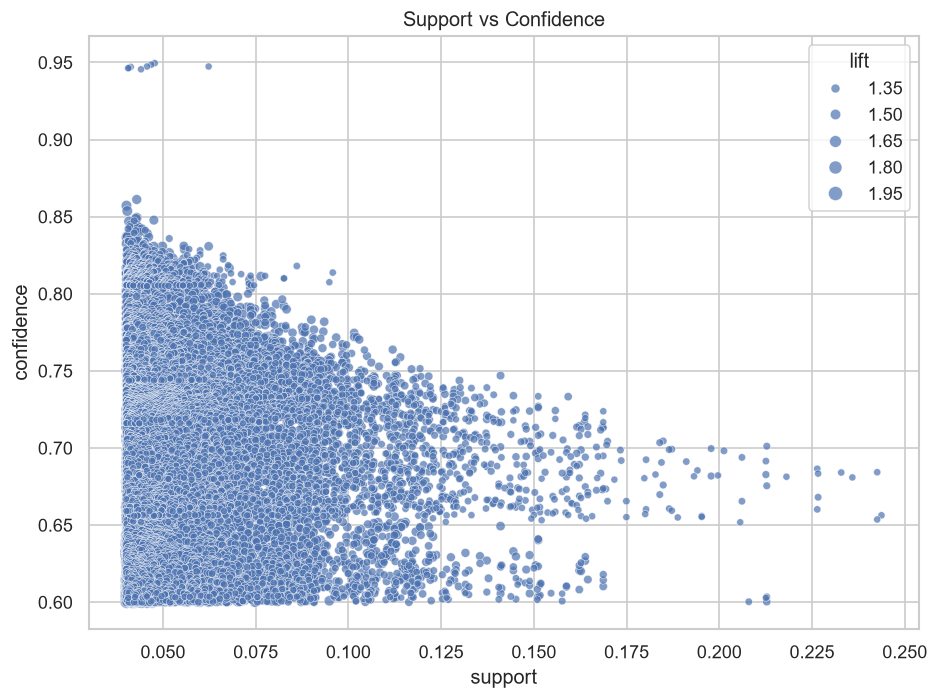

In [68]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rules,
    x="support",
    y="confidence",
    size="lift",
    alpha=0.7
)

plt.title("Support vs Confidence")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"support_confidence_scatter.png",
    dpi=300
)

plt.show()

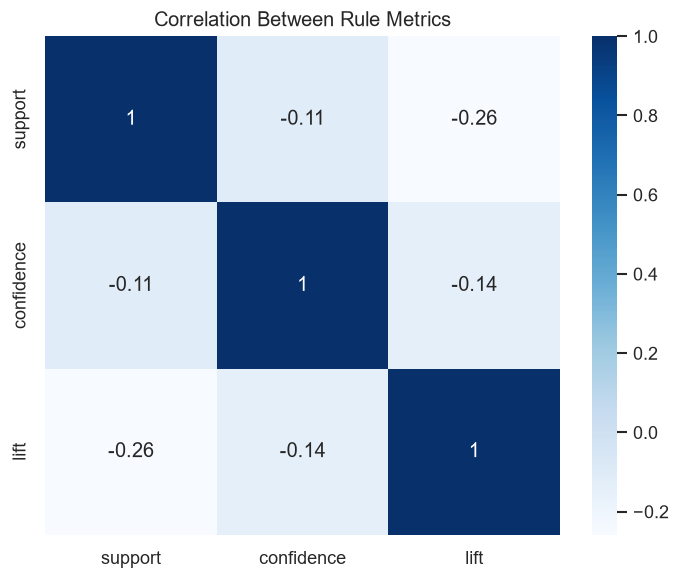

In [69]:
metrics = rules[
    ["support","confidence","lift"]
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    metrics,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Between Rule Metrics")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"rule_metric_heatmap.png",
    dpi=300
)

plt.show()

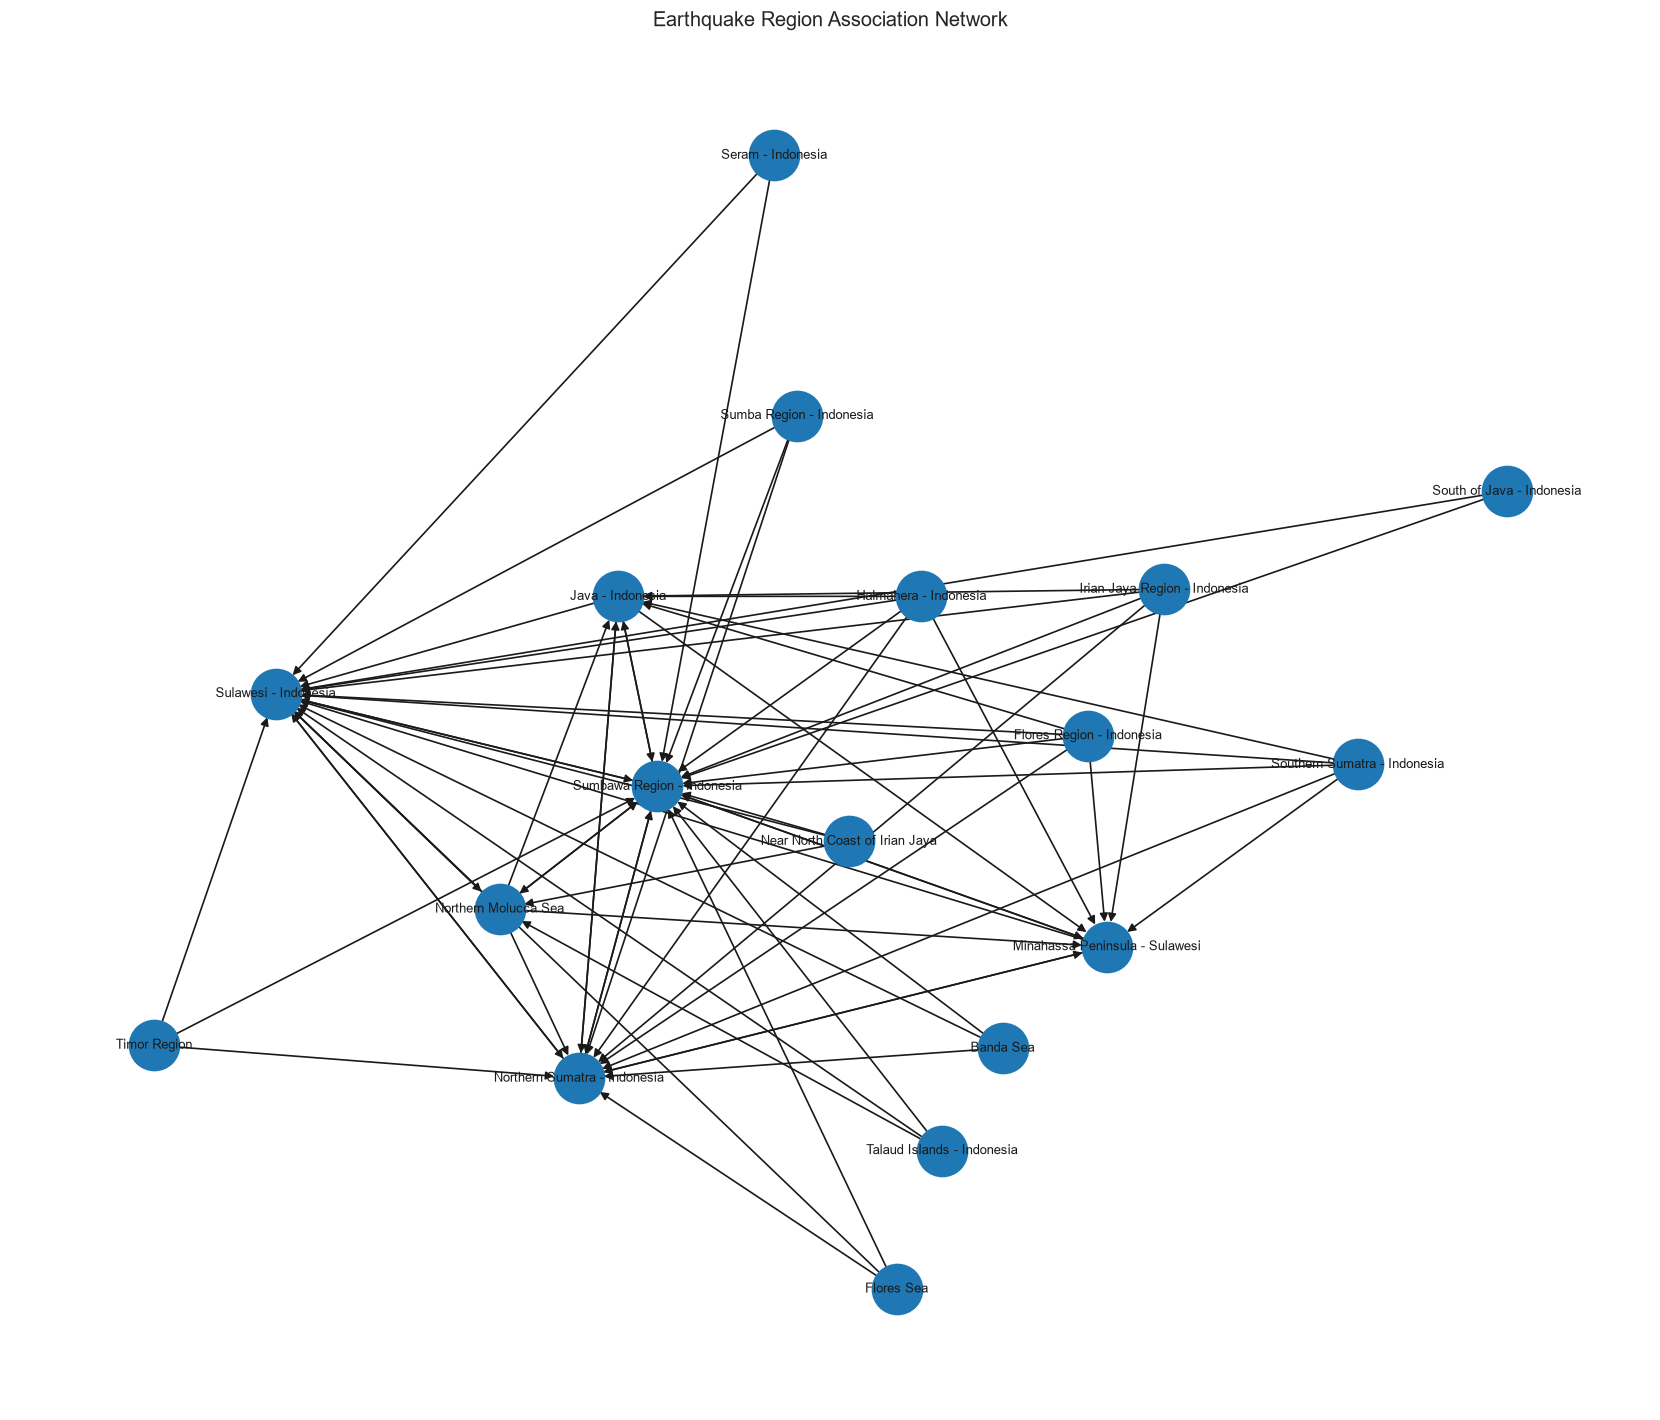

In [72]:
import networkx as nx

G = nx.DiGraph()

top_network = rules.sort_values(
    "lift",
    ascending=False
).head(40)

for _, row in top_network.iterrows():

    for a in row["antecedents"].split(", "):

        for c in row["consequents"].split(", "):

            G.add_edge(
                a,
                c,
                weight=row["lift"]
            )

plt.figure(figsize=(14,12))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx(
    G,
    pos,
    node_size=900,
    font_size=8,
    arrows=True
)

plt.title("Earthquake Region Association Network")

plt.axis("off")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR/"images"/"association_network.png",
    dpi=300
)

plt.show()

In [73]:
top_rules.to_csv(
    PROJECT_DIR/"results"/"top_rules.csv",
    index=False
)

# 15. Insights & Interpretation

This section summarizes the main findings obtained from the Association Rule Mining process and answers the research questions proposed at the beginning of this project.

---

## Research Question 1

### Which earthquake regions frequently experience earthquakes together?

The Apriori algorithm identified **11,708 frequent itemsets** using a minimum support threshold of **4%**.

Among all single-region itemsets, the most frequently occurring regions are:

| Region | Support |
|---------|---------|
| Minahassa Peninsula - Sulawesi | 0.787 |
| Java - Indonesia | 0.671 |
| Banda Sea | 0.620 |
| Northern Sumatra - Indonesia | 0.598 |
| Southern Sumatra - Indonesia | 0.597 |

### Interpretation

Minahassa Peninsula – Sulawesi appears in nearly **79%** of all daily transactions, making it the most frequently occurring earthquake region in the dataset.

Several regions, including Java, Banda Sea, Northern Sumatra, and Southern Sumatra, also exhibit consistently high occurrence frequencies. These regions become the dominant building blocks of many frequent itemsets discovered during the mining process.

This result indicates that earthquake activity is concentrated in several major seismic regions rather than being uniformly distributed across Indonesia.

---

## Research Question 2

### How strong are the discovered regional associations?

After applying the Association Rule algorithm with:

- Minimum Confidence = **0.60**
- Minimum Lift = **1.20**

the analysis produced:

| Metric | Value |
|---------|------:|
| Total Association Rules | 27,129 |
| Average Support | 0.057 |
| Average Confidence | 0.698 |
| Average Lift | 1.335 |
| Maximum Lift | 1.966 |

### Interpretation

The average confidence of approximately **70%** indicates that when the antecedent pattern occurs, the consequent is also observed in roughly seven out of ten transactions.

The average lift value of **1.33** shows that the discovered associations occur approximately **33% more frequently than expected under statistical independence**.

Overall, the generated rules demonstrate moderate to strong positive associations between earthquake regions.

---

## Research Question 3

### Which association rule is the strongest?

The strongest rule discovered achieved:

- Support = **0.043**
- Confidence = **0.619**
- Lift = **1.966**

The rule consists of:

Antecedent

- Halmahera - Indonesia
- Irian Jaya Region - Indonesia
- Java - Indonesia
- Southern Sumatra - Indonesia
- Sumbawa Region - Indonesia

Consequent

- Minahassa Peninsula - Sulawesi
- Northern Sumatra - Indonesia
- Sulawesi - Indonesia

### Interpretation

This rule has the highest lift among all discovered association rules, indicating that these groups of regions co-occur almost **twice as frequently** as would be expected if they were statistically independent.

It is important to emphasize that Association Rule Mining **does not imply causal relationships**. The rule should therefore be interpreted as a strong statistical co-occurrence pattern rather than evidence that earthquakes in one region cause earthquakes in another.

---

## Research Question 4

### What does the association network reveal?

The association network visualization illustrates how earthquake regions are interconnected through the discovered association rules.

Several regions appear repeatedly as highly connected nodes within the network, including:

- Minahassa Peninsula – Sulawesi
- Java – Indonesia
- Northern Sumatra – Indonesia
- Sumbawa Region – Indonesia
- Halmahera – Indonesia

### Interpretation

These highly connected regions participate in numerous association rules and therefore play an important role in the overall structure of the discovered earthquake association network.

Rather than isolated earthquake occurrences, the network suggests that seismic activity often forms interconnected regional patterns involving multiple geographic locations within the same temporal observation window.

---

## Overall Findings

The complete Association Rule Mining pipeline successfully transformed more than **91,000 historical earthquake events** into meaningful spatial-temporal knowledge.

The analysis produced:

- **4,333 daily transactions**
- **51 earthquake regions**
- **11,708 frequent itemsets**
- **27,129 association rules**
- Average Confidence = **69.8%**
- Average Lift = **1.33**

These findings demonstrate that earthquake records contain numerous statistically meaningful regional co-occurrence patterns that cannot be observed through raw event tables alone.

Although these patterns do **not** provide earthquake prediction capability, they reveal valuable structural relationships within Indonesia's historical seismic activity and demonstrate how unsupervised learning can be applied to extract interpretable knowledge from large-scale geospatial datasets.

# 16. Conclusion

## Summary

This project demonstrates a complete end-to-end Association Rule Mining pipeline for discovering spatial-temporal earthquake patterns from the Indonesian earthquake catalog.

Starting from **91,395 historical earthquake events**, the raw seismic records were transformed into **4,333 daily transactions** representing earthquake activity across **51 seismic regions**.

Using the Apriori algorithm with a minimum support threshold of **4%**, the analysis successfully identified:

- **11,708 frequent itemsets**
- **27,129 association rules**
- Average Confidence = **69.8%**
- Average Lift = **1.33**

These results indicate that meaningful regional co-occurrence patterns exist within Indonesia's historical earthquake records.

---

## Research Questions Revisited

### RQ1
**Which earthquake regions frequently co-occur?**

The analysis identified numerous regional combinations that repeatedly appeared within the same daily observation window. Regions such as **Minahassa Peninsula – Sulawesi**, **Java**, **Banda Sea**, **Northern Sumatra**, and **Southern Sumatra** appeared most frequently across transactions.

---

### RQ2
**How strong are these associations?**

The discovered rules achieved an average confidence of approximately **70%** and an average lift of **1.33**, indicating moderate to strong positive associations beyond random coincidence.

---

### RQ3
**Are recurring spatial-temporal patterns present?**

Yes.

The discovered frequent itemsets and association rules demonstrate recurring co-occurrence patterns among multiple earthquake regions throughout the 14-year observation period.

---

## Project Contributions

This project demonstrates:

- End-to-end data science workflow
- Data quality assessment
- Exploratory Data Analysis
- Transaction engineering for non-transactional data
- Association Rule Mining using Apriori
- Statistical evaluation of association rules
- Professional visualization and interpretation
- Reproducible analysis pipeline

---

## Limitations

Several limitations should be acknowledged:

- Association rules describe statistical co-occurrence rather than causal relationships.
- One calendar day was used as the observation window, and different temporal windows may produce different association structures.
- Rare earthquake regions contribute relatively few transactions, limiting their representation in the discovered rules.
- This project focuses on historical pattern discovery rather than earthquake prediction.

---

## Future Work

Future research may extend this work by:

- Comparing multiple temporal observation windows.
- Incorporating earthquake magnitude categories into transactions.
- Applying Sequential Pattern Mining to capture temporal ordering.
- Constructing weighted earthquake association networks.
- Comparing Apriori with FP-Growth and ECLAT algorithms.

---

## Final Remarks

This project shows that Association Rule Mining can successfully transform large-scale historical earthquake records into interpretable knowledge about regional seismic co-occurrence patterns.

Although the methodology is not intended for earthquake prediction, it provides a transparent and reproducible framework for exploring hidden relationships within complex geospatial event data while demonstrating practical applications of unsupervised learning in Earth science.